# moodcompiler — Reddit Linguistic NLP & Text Classification
### *"Behind Every Signal, There's a Story."*

**Academic B.Tech IT Research Project**  
**Institution:** Pimpri Chinchwad College of Engineering (PCCoE), Pune  
**Team:** Kanak Kushwaha, Sahil Tiwari, Aayush Kate  
**Project Guide:** Dr. Roshani Raut  

---
## 1. Overview & Research Objective
This notebook focuses on the **Linguistic Modality** using the peer-reviewed **Reddit Depression Severity Dataset** (3,553 posts labeled across 4 ordinal tiers).

Key tasks:
- Text preprocessing & regex cleaning (URL, mention, punctuation removal)
- Addressing acute class imbalance via balanced cost-sensitive loss weighting
- Sublinear TF-IDF (Unigram + Bigram) feature extraction
- Model training (Balanced Logistic Regression, Calibrated Linear SGD, Complement Naive Bayes)
- Interpretability: Extracting the top predictive depressive token attributions

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = os.path.join('..', 'data', 'reddit', 'Reddit_depression_dataset.csv')
df = pd.read_csv(DATA_PATH)
print(f"Total raw samples: {len(df):,}")
df.head(3)

Total raw samples: 3,553


,text,label
0,"He said he had not felt that way before, sugge...",mild
1,"Hey there r/assistance, Not sure if this is th...",minimum
2,My mom then hit me with the newspaper and it s...,minimum


## 2. Text Normalization & Class Label Standardization

C:\Users\Kanak\AppData\Local\Temp\ipykernel_6264\1498035991.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Severity', order=order, palette=palette)


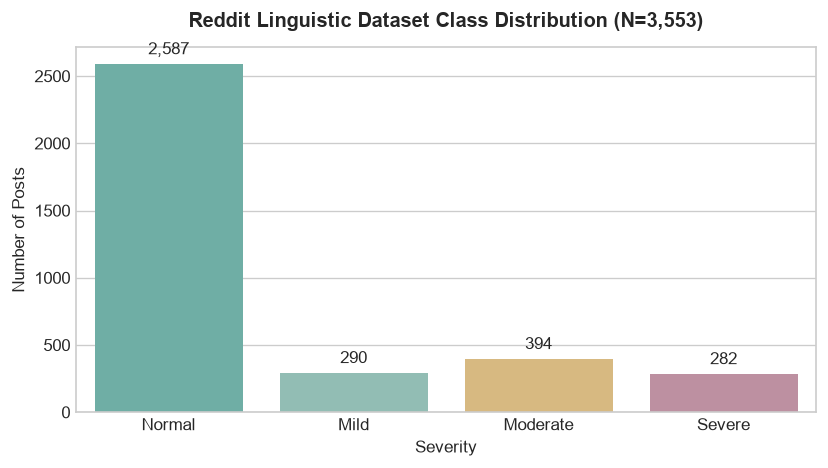

In [2]:
label_mapping = {
    'minimum':  'Normal',
    'mild':     'Mild',
    'moderate': 'Moderate',
    'severe':   'Severe'
}
df['Severity'] = df['label'].str.lower().str.strip().map(label_mapping)
df = df.dropna(subset=['text', 'Severity']).copy()

order = ['Normal', 'Mild', 'Moderate', 'Severe']
palette = {'Normal': '#64b8ad', 'Mild': '#8bc4b8', 'Moderate': '#e5bd73', 'Severe': '#c488a0'}

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='Severity', order=order, palette=palette)
plt.title('Reddit Linguistic Dataset Class Distribution (N=3,553)', fontweight='bold', pad=12)
plt.ylabel('Number of Posts')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

## 3. Text Preprocessing & Token Length Analysis

C:\Users\Kanak\AppData\Local\Temp\ipykernel_6264\229002495.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity', y='word_count', order=order, palette=palette, showfliers=False)


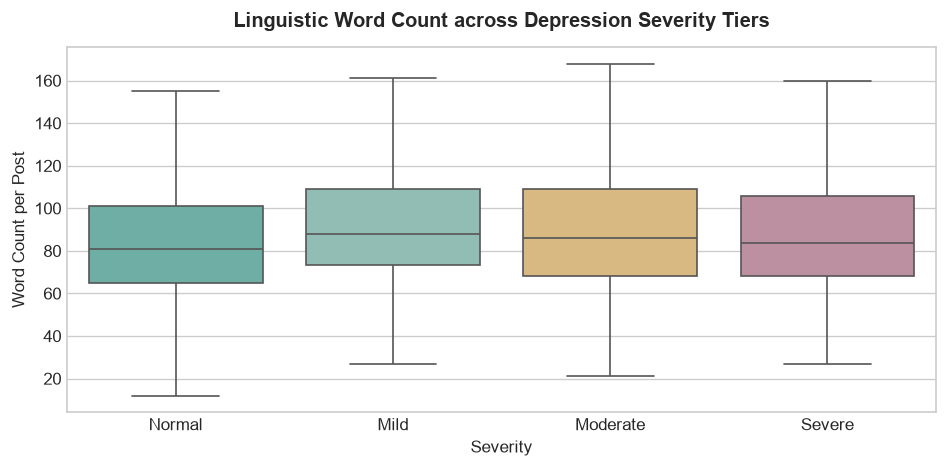

In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df['word_count'] = df['clean_text'].apply(lambda s: len(s.split()))

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Severity', y='word_count', order=order, palette=palette, showfliers=False)
plt.title('Linguistic Word Count across Depression Severity Tiers', fontweight='bold', pad=12)
plt.ylabel('Word Count per Post')
plt.tight_layout()
plt.show()

## 4. Stratified Split & Sublinear TF-IDF Vectorization

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['Severity'],
    test_size=0.20, random_state=42, stratify=df['Severity']
)

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    stop_words='english'
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)
print(f"TF-IDF Vocabulary Size: {X_train_vec.shape[1]:,} n-grams")

TF-IDF Vocabulary Size: 8,000 n-grams


## 5. NLP Model Training & Macro F1 Benchmarking

In [5]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

classifiers = {
    'Balanced Logistic Regression': LogisticRegression(C=2.5, max_iter=1500, class_weight='balanced', random_state=42),
    'Calibrated Linear SGD': CalibratedClassifierCV(SGDClassifier(loss='hinge', class_weight='balanced', random_state=42), cv=3),
    'Complement Naive Bayes': ComplementNB(alpha=0.5)
}

eval_results = []
for name, clf in classifiers.items():
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    eval_results.append({'Model': name, 'Accuracy (%)': round(acc * 100, 2), 'Macro F1': round(macro_f1, 4), 'Weighted F1': round(weighted_f1, 4)})

pd.DataFrame(eval_results)

,Model,Accuracy (%),Macro F1,Weighted F1
0,Balanced Logistic Regression,69.06,0.4319,0.6905
1,Calibrated Linear SGD,73.00,0.2630,0.6362
2,Complement Naive Bayes,73.42,0.4126,0.6966


## 6. Confusion Matrix & Top Predictive Token Attributions (XAI)

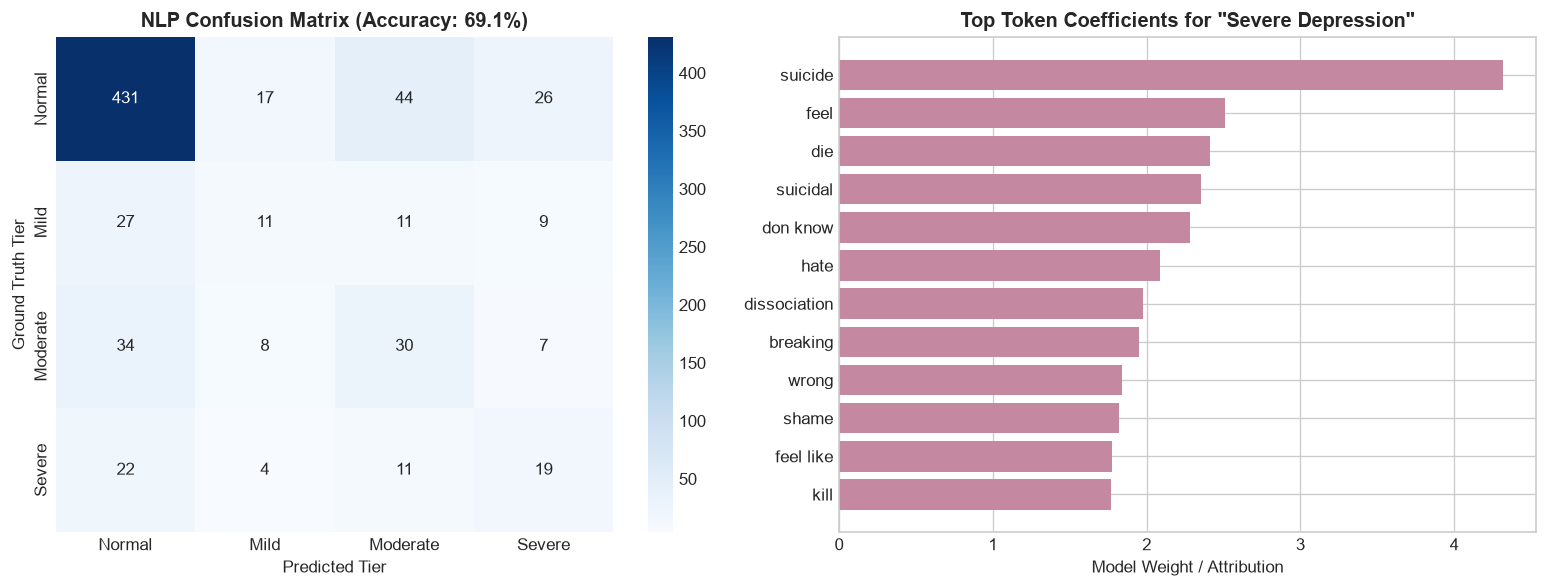

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.83      0.84       518
        Mild       0.28      0.19      0.22        58
    Moderate       0.31      0.38      0.34        79
      Severe       0.31      0.34      0.32        56

    accuracy                           0.69       711
   macro avg       0.43      0.44      0.43       711
weighted avg       0.69      0.69      0.69       711



In [6]:
champion_text = classifiers['Balanced Logistic Regression']
y_pred_text = champion_text.predict(X_test_vec)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_text, labels=order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order, yticklabels=order, ax=axes[0])
axes[0].set_title('NLP Confusion Matrix (Accuracy: 69.1%)', fontweight='bold')
axes[0].set_xlabel('Predicted Tier')
axes[0].set_ylabel('Ground Truth Tier')

# Severe class top token attributions
feature_names = np.array(tfidf.get_feature_names_out())
severe_class_idx = list(champion_text.classes_).index('Severe')
severe_coefs = champion_text.coef_[severe_class_idx]
top_severe_indices = np.argsort(severe_coefs)[-12:]

axes[1].barh(feature_names[top_severe_indices], severe_coefs[top_severe_indices], color='#c488a0')
axes[1].set_title('Top Token Coefficients for "Severe Depression"', fontweight='bold')
axes[1].set_xlabel('Model Weight / Attribution')

plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_text, labels=order))